# Cuantificación

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

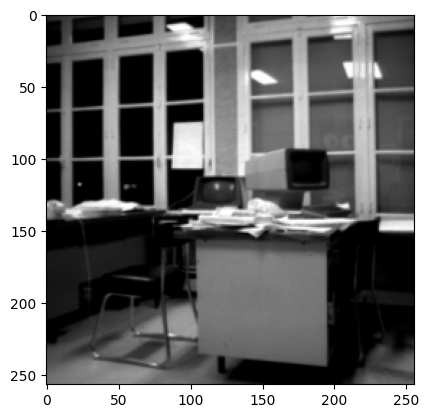

In [4]:
BUREAU = cv2.imread("../img/BUREAU.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(BUREAU, cmap='gray')
plt.show()

In [5]:
def bit_plane_slicing(imagen, k):
    plane = np.full((imagen.shape[0], imagen.shape[1]), 2 ** k, np.uint8)
    return cv2.bitwise_and(plane, imagen)

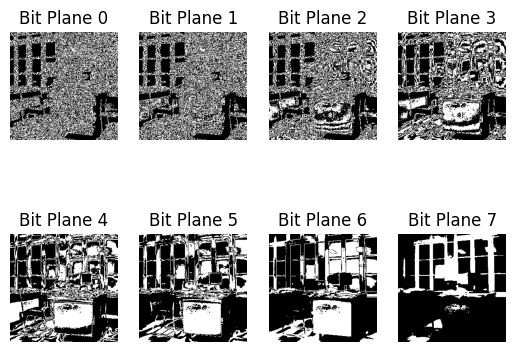

In [6]:
for k in range(8):
    bp = bit_plane_slicing(BUREAU, k)
    plt.subplot(2, 4, k + 1)
    plt.imshow(bp, cmap='gray')
    plt.title(f'Bit Plane {k}')
    plt.axis('off')

Aunque la teoría establece que el plano más significativo (bit 7) es el más importante desde el punto de vista de la representación numérica, en esta imagen en particular el plano que visualmente muestra con mayor claridad las formas principales es el plano 4. Esto ocurre porque la distribución de intensidades de la imagen no utiliza plenamente el rango  alto, sino que está concentrada en valores intermedios. Por ello, los bits de peso medio contienen gran parte de la información visible.

In [7]:
# Apagar un plano 
def image_quantization(imagen, k):
    plane = np.full((imagen.shape[0], imagen.shape[1]), 255-2 ** k, np.uint8)
    return cv2.bitwise_and(plane, imagen)



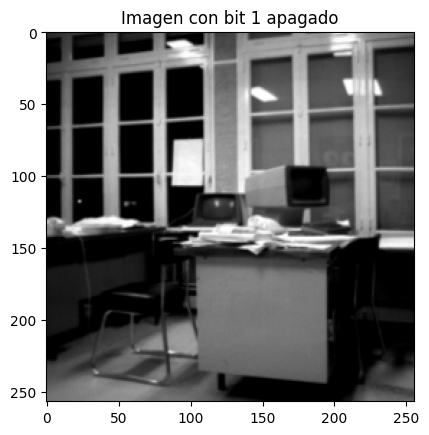

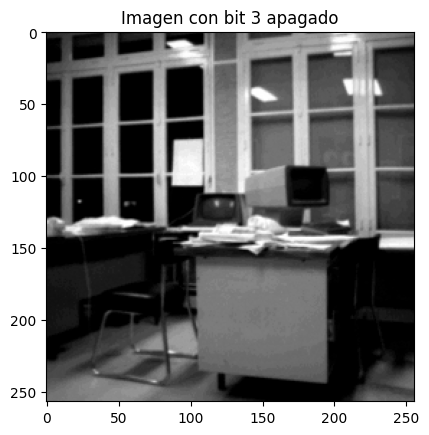

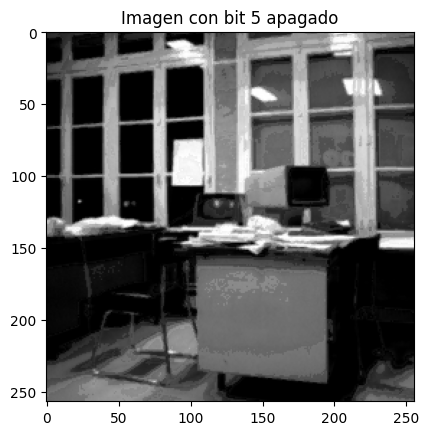

In [8]:
removal_bits= [1, 3, 5]

quantized_image = BUREAU.copy()
for bit in removal_bits:
    quantized_image1 = image_quantization(quantized_image, bit-1)
    plt.imshow(quantized_image1, cmap='gray')
    plt.title(f'Imagen con bit {bit} apagado')
    plt.show()


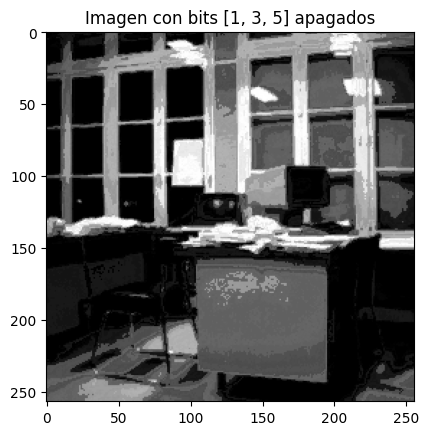

In [9]:
quantized_image = BUREAU.copy()
for bit in removal_bits:
    quantized_image = image_quantization(quantized_image, bit)
plt.imshow(quantized_image, cmap='gray')
plt.title(f'Imagen con bits {removal_bits} apagados')
plt.show()

En estos resultados se observa que los planos de bits más altos sostienen la estructura y el contraste global de la escena, mientras que los bits menos significativos aportan principalmente detalles finos y pequeñas variaciones de intensidad. Al desactivar el bit menos significativo (bit 1), prácticamente no se perciben cambios visuales en la imagen. Al apagar el bit 3, se aprecia una leve suavización, como si la imagen estuviera ligeramente desenfocada, aunque su apariencia general se mantiene. En cambio, al eliminar el bit 5, la pérdida de información es más evidente: disminuye la calidad visual, se reducen algunos matices de color o gris y aparece un efecto de posterización, haciendo que la imagen se vea menos detallada.

Cuando se desactivan simultáneamente los bits 1, 3 y 5, la distorsión se hace más notable, predominando el efecto causado por la eliminación del bit 5. Aunque las alteraciones debidas a los bits menos significativos siguen presentes, resultan menos perceptibles a simple vista. Es decir, los bits de mayor peso son responsables de la luminancia y de las formas principales de la imagen, mientras que los bits de menor peso pueden eliminarse parcialmente con un impacto visual reducido; sin embargo, al suprimir bits más significativos, la degradación en la calidad percibida se vuelve evidente.